In [48]:
import pandas as pd
df= pd.read_csv("cleaned_flights_sample_3m.csv", low_memory=False)

In [49]:
import pandas as pd                 # data handling
import numpy as np                  # numeric ops
import matplotlib.pyplot as plt     # base plotting
import seaborn as sns               # nicer plots
sns.set_theme(style="whitegrid")    # nicer default look


df_sample = df.sample(frac=0.02, random_state=42)  # ~2% of data for quick plots


C:\Users\admin\AppData\Local\Temp\ipykernel_11604\3555687987.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=airline_counts.values, y=airline_counts.index, palette='magma')


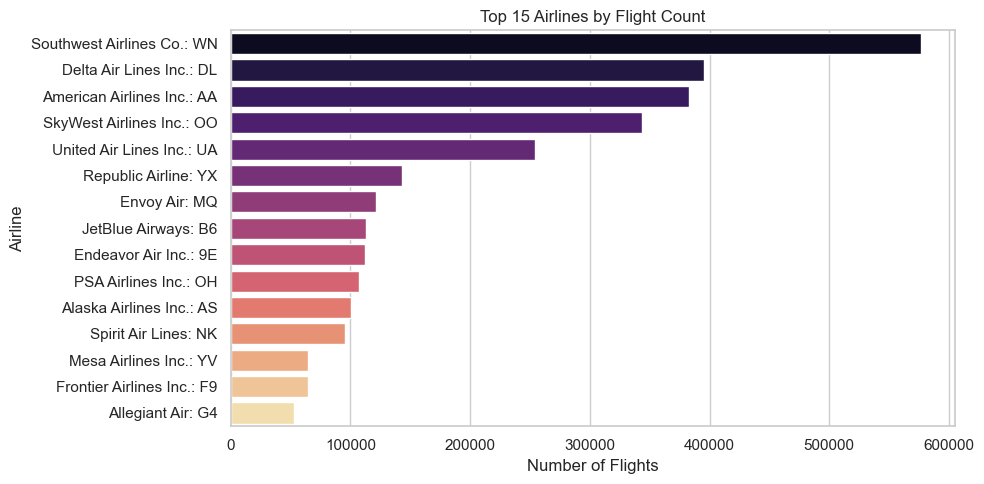

In [50]:
# week 3 and 4
# Top 15 airlines by number of flights 
airline_counts = df['AIRLINE_DOT'].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(x=airline_counts.values, y=airline_counts.index, palette='magma')
plt.title("Top 15 Airlines by Flight Count")
plt.xlabel("Number of Flights")
plt.ylabel("Airline")
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_11604\958587364.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=route_counts.values, y=route_counts.index, palette='viridis')


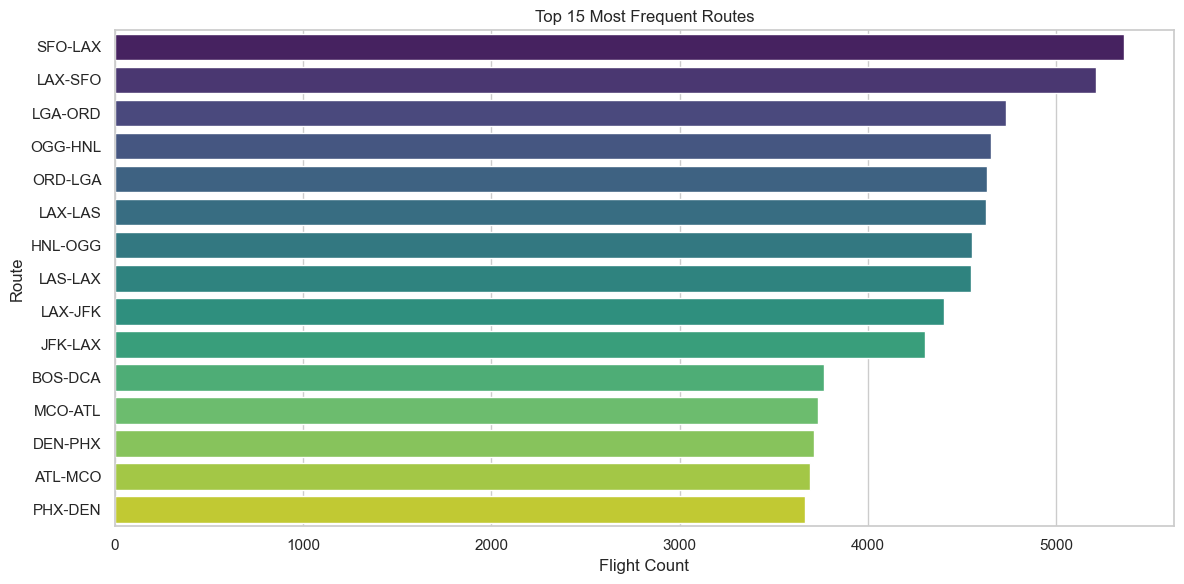

In [51]:
#top bussiest routes
df['ROUTE'] = df['ORIGIN'].astype(str) + '-' + df['DEST'].astype(str)

route_counts = df['ROUTE'].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=route_counts.values, y=route_counts.index, palette='viridis')
plt.title("Top 15 Most Frequent Routes")
plt.xlabel("Flight Count")
plt.ylabel("Route")
plt.tight_layout()
plt.show()


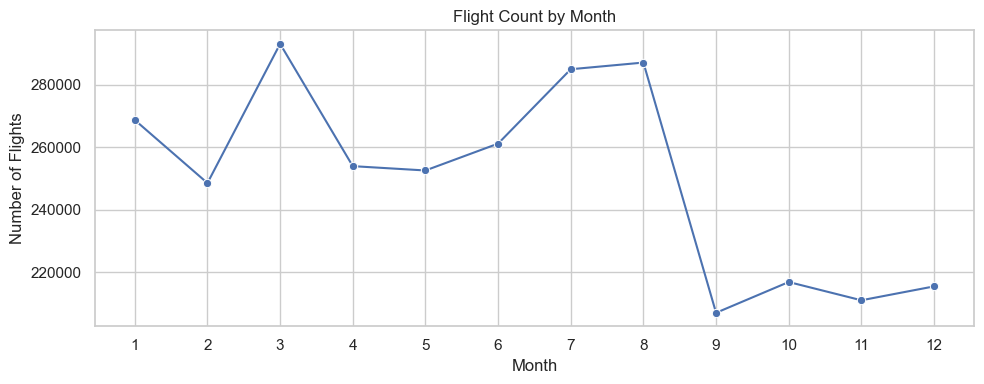

In [52]:
# flight count by month- (mont 3, 7, 8 has highest number of flights)
# bussiest months(3, 7, 8)
month_mean_count = df.groupby('MONTH').size().reindex(range(1,13), fill_value=0)
plt.figure(figsize=(10,4))
sns.lineplot(x=month_mean_count.index, y=month_mean_count.values, marker='o')
plt.title("Flight Count by Month")
plt.xlabel("Month")
plt.ylabel("Number of Flights")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()


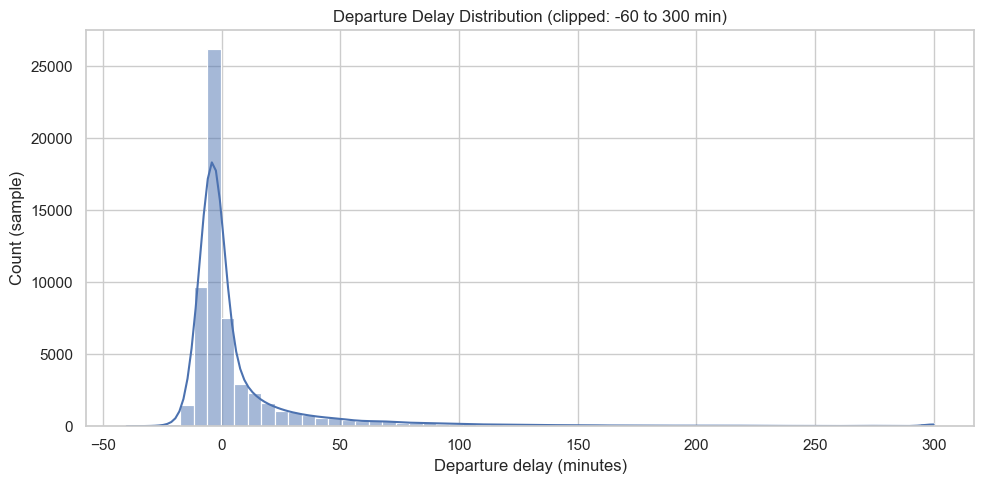

In [53]:
# week 4 (delay analysis)
plt.figure(figsize=(10,5))
sns.histplot(df_sample['DEP_DELAY'].dropna().clip(lower=-60, upper=300), bins=60, kde=True)
plt.title("Departure Delay Distribution (clipped: -60 to 300 min)")
plt.xlabel("Departure delay (minutes)")
plt.ylabel("Count (sample)")
plt.tight_layout()
plt.show()


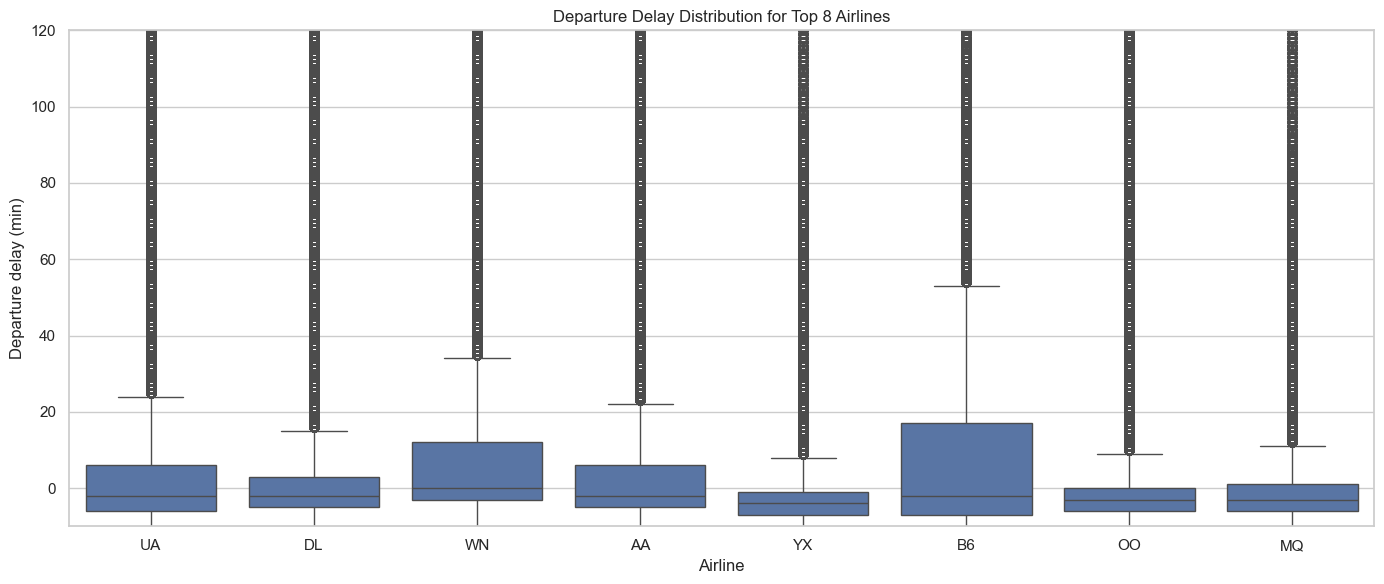

In [54]:
# departure delay 
plt.figure(figsize=(14,6))
top_airlines = df['AIRLINE_CODE'].value_counts().head(8).index.tolist()
sub = df[df['AIRLINE_CODE'].isin(top_airlines)]
sns.boxplot(data=sub, x='AIRLINE_CODE', y='DEP_DELAY')
plt.title("Departure Delay Distribution for Top 8 Airlines")
plt.xlabel("Airline")
plt.ylabel("Departure delay (min)")
plt.ylim(-10, 120)   # zoom to see spread
plt.tight_layout()
plt.show()


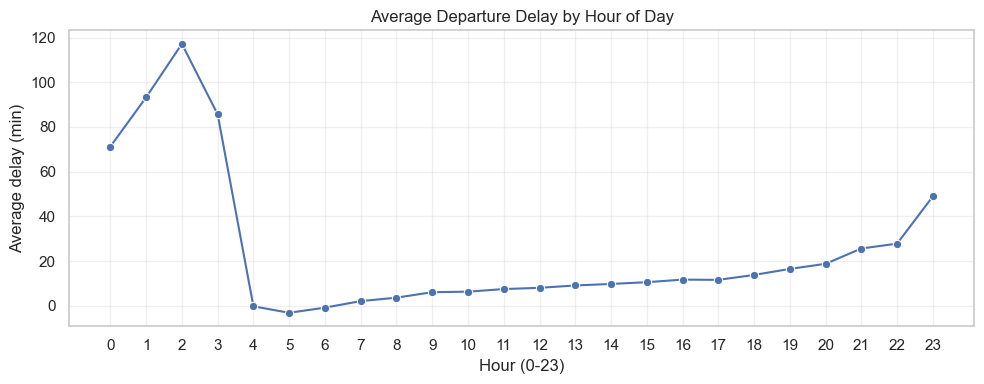

In [55]:
#Delay by Hour of Day 
hour_mean = df.groupby('DEP_HOUR')['DEP_DELAY'].mean().reindex(range(0,24))
plt.figure(figsize=(10,4))
sns.lineplot(x=hour_mean.index, y=hour_mean.values, marker='o')
plt.title("Average Departure Delay by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Average delay (min)")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


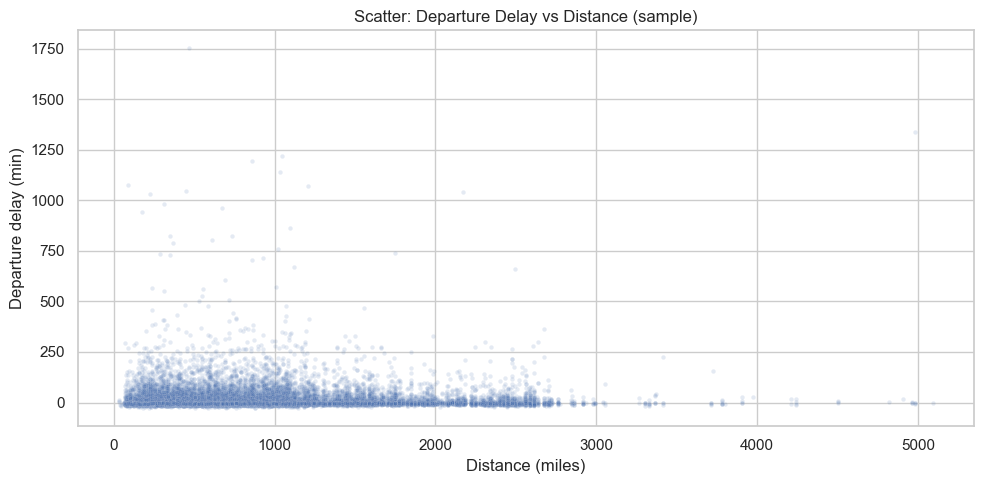

In [56]:
#Delay vs Distance
sample2 = df_sample.dropna(subset=['DISTANCE','DEP_DELAY'])
plt.figure(figsize=(10,5))
sns.scatterplot(data=sample2.sample(min(30000, len(sample2)), random_state=42),
                x='DISTANCE', y='DEP_DELAY', alpha=0.15, s=10)
plt.title("Scatter: Departure Delay vs Distance (sample)")
plt.xlabel("Distance (miles)")
plt.ylabel("Departure delay (min)")
plt.tight_layout()
plt.show()


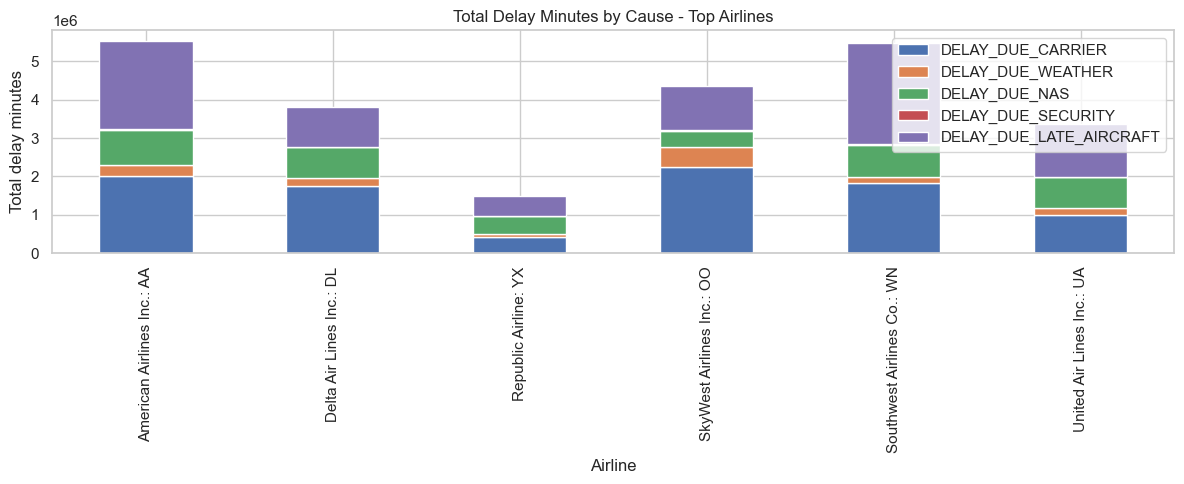

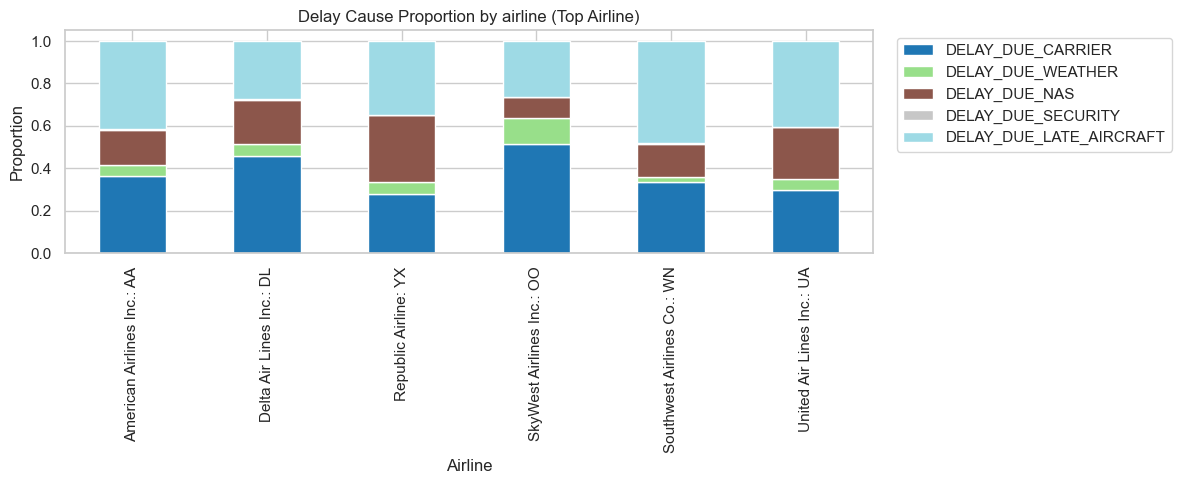

In [57]:
# sum of each delay type by carrier (top carriers)
delay_cols = ['DELAY_DUE_CARRIER','DELAY_DUE_WEATHER','DELAY_DUE_NAS','DELAY_DUE_SECURITY','DELAY_DUE_LATE_AIRCRAFT']
top_airline = df['AIRLINE_DOT'].value_counts().head(6).index
agg = df[df['AIRLINE_DOT'].isin(top_airline)].groupby('AIRLINE_DOT')[delay_cols].sum()

# Absolute stacked bar
agg.plot(kind='bar', stacked=True, figsize=(12,5))
plt.title("Total Delay Minutes by Cause - Top Airlines")
plt.xlabel("Airline")
plt.ylabel("Total delay minutes")
plt.tight_layout()
plt.show()

# Normalized (proportion)
prop = agg.div(agg.sum(axis=1), axis=0)
prop.plot(kind='bar', stacked=True, figsize=(12,5), colormap='tab20')
plt.title("Delay Cause Proportion by airline (Top Airline)")
plt.xlabel("Airline")
plt.ylabel("Proportion")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_11604\1289973807.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_airports['mean'].values, y=top_airports.index, palette='plasma')


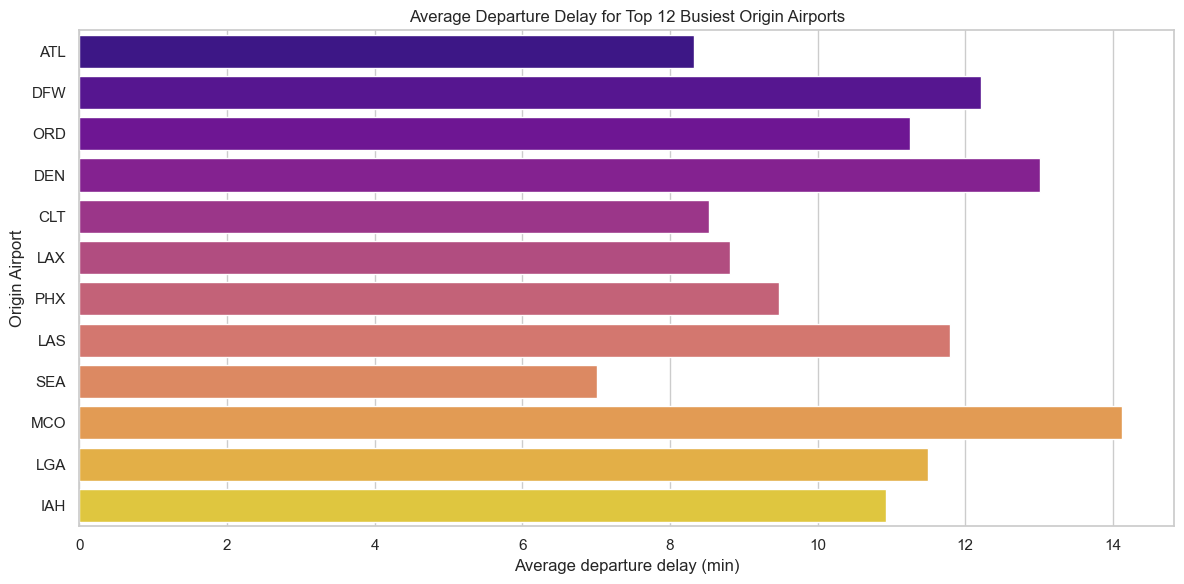

In [58]:
#Delay by airport (busiest vs avg delay)
airport_stats = df.groupby('ORIGIN')['DEP_DELAY'].agg(['mean','count']).sort_values('count', ascending=False)
top_airports = airport_stats.head(12)
plt.figure(figsize=(12,6))
sns.barplot(x=top_airports['mean'].values, y=top_airports.index, palette='plasma')
plt.title("Average Departure Delay for Top 12 Busiest Origin Airports")
plt.xlabel("Average departure delay (min)")
plt.ylabel("Origin Airport")
plt.tight_layout()
plt.show()


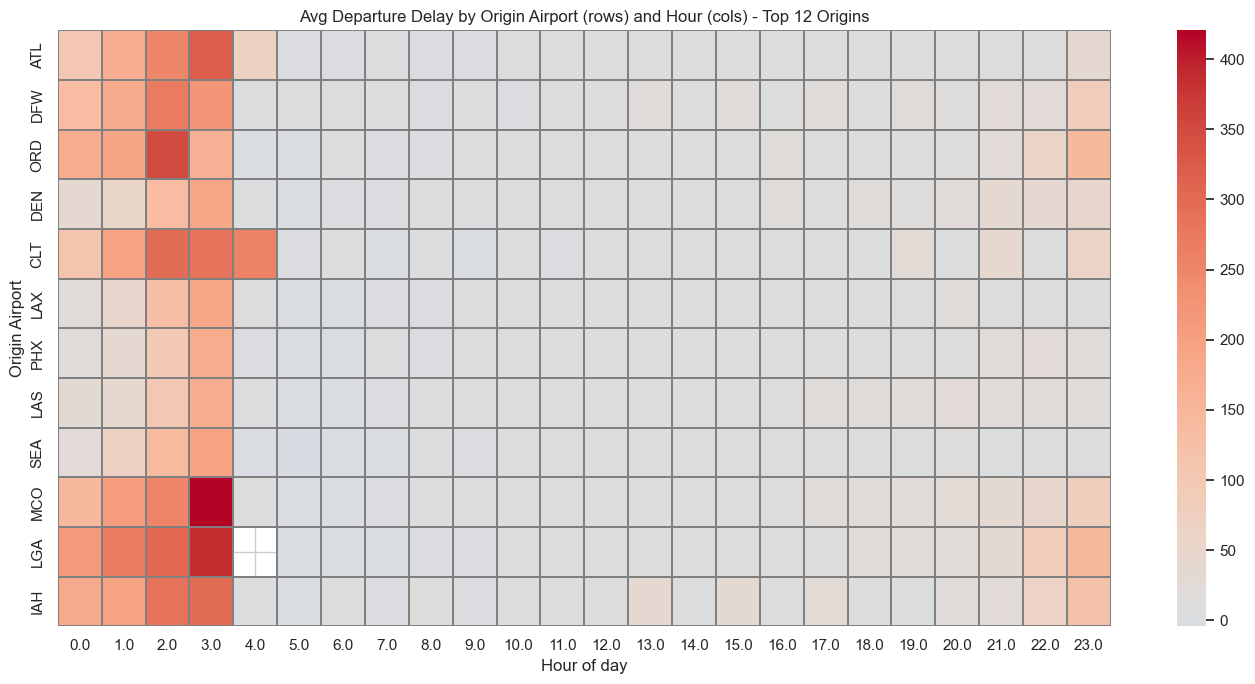

In [59]:
#Heatmap: Average delay per (origin airport × hour)
pivot = df.pivot_table(values='DEP_DELAY', index='ORIGIN', columns='DEP_HOUR', aggfunc='mean').fillna(np.nan)
# restrict to top 12 busiest origins
top_origin_codes = df['ORIGIN'].value_counts().head(12).index
pivot_sub = pivot.loc[top_origin_codes]
plt.figure(figsize=(14,7))
sns.heatmap(pivot_sub, cmap='coolwarm', center=np.nanmean(df['DEP_DELAY']), linewidths=0.3, linecolor='gray')
plt.title("Avg Departure Delay by Origin Airport (rows) and Hour (cols) - Top 12 Origins")
plt.xlabel("Hour of day")
plt.ylabel("Origin Airport")
plt.tight_layout()
plt.show()


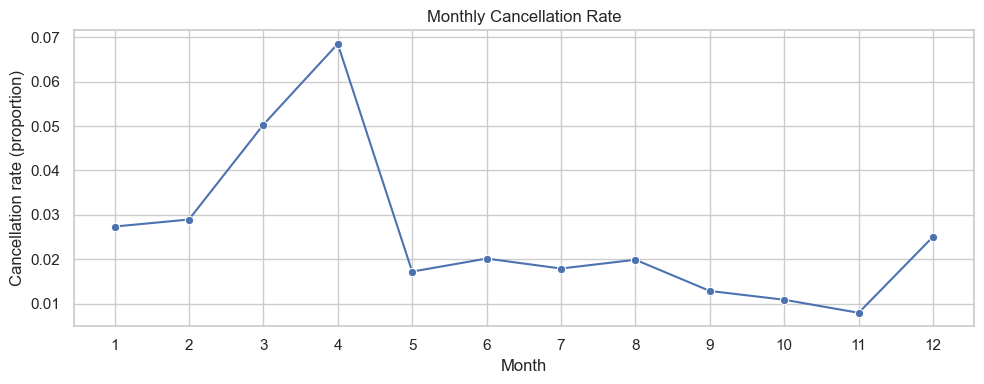

In [60]:
#week 5 and week 6
# cancellation column = CANCELLED (0/1)
monthly_cancel = df.groupby('MONTH')['CANCELLED'].mean().reindex(range(1,13), fill_value=0)
plt.figure(figsize=(10,4))
sns.lineplot(x=monthly_cancel.index, y=monthly_cancel.values, marker='o')
plt.title("Monthly Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation rate (proportion)")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()


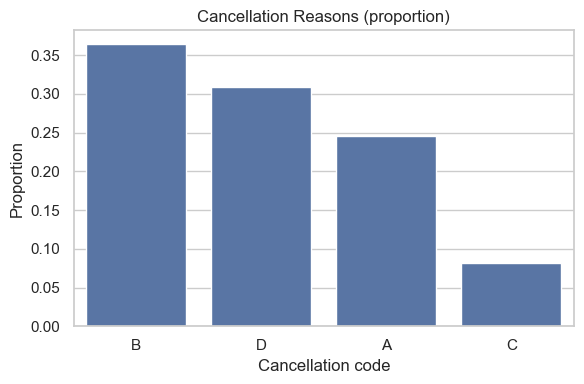

In [61]:
# CANCELLATION_CODE often has values like A,B,C,D or NaN
#Cancellation types: carrier, weather, security, NAS 
cancel_counts = df[df['CANCELLED']==1]['CANCELLATION_CODE'].value_counts(normalize=True)
plt.figure(figsize=(6,4))
sns.barplot(x=cancel_counts.index, y=cancel_counts.values)
plt.title("Cancellation Reasons (proportion)")
plt.xlabel("Cancellation code")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()
